In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv('../Datasets/height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

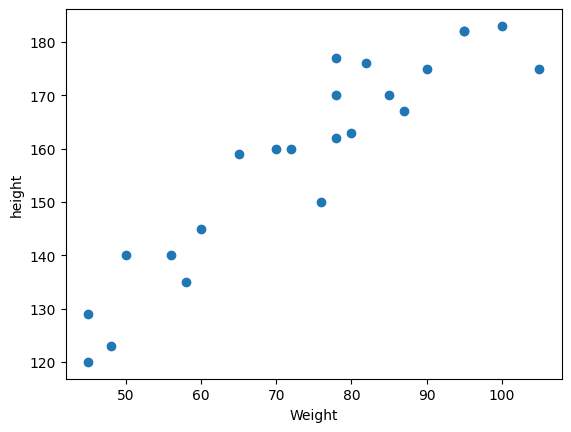

In [3]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('height')

In [6]:
df.isna().sum()

Weight    0
Height    0
dtype: int64

In [7]:
X = df.drop('Height', axis=1)
y = df['Height']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((17, 1), (6, 1), (17,), (6,))

In [11]:
## Standardize the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [12]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

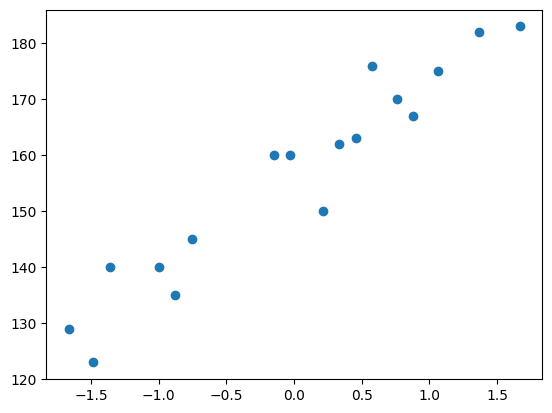

In [13]:
plt.scatter(X_train_scaled, y_train)

In [14]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [16]:
lin_reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
lin_reg.coef_

array([17.2982057])

In [18]:
lin_reg.intercept_

np.float64(156.47058823529412)

In [19]:
y_pred = lin_reg.predict(X_test_scaled)

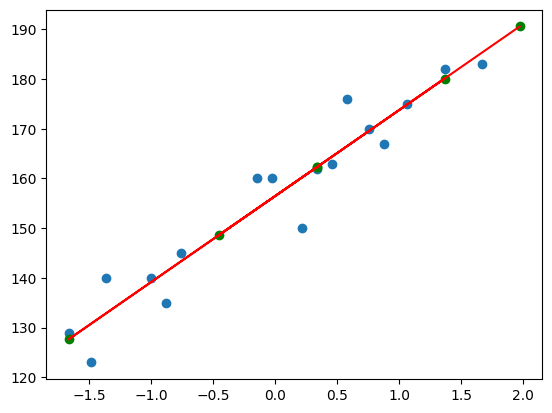

In [21]:
plt.scatter(X_train_scaled, y_train)
plt.plot(X_test_scaled, y_pred, color='r')
plt.scatter(X_test_scaled, y_pred, color='g')

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
print('mse ', mean_squared_error(y_test, y_pred))
print('mae ', mean_absolute_error(y_test, y_pred))
print('r2 score ', r2_score(y_test, y_pred))

mse  114.84069295228699
mae  9.66512588679501
r2 score  0.7360826717981276


<Axes: xlabel='Height', ylabel='Count'>

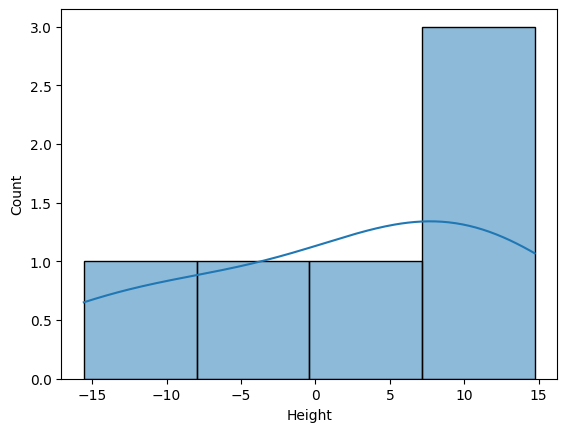

In [ ]:
## plot a scatter plot for the residuals
sns.histplot(y_test-y_pred, kde=True) ## -- this should be in an almost normal distribution

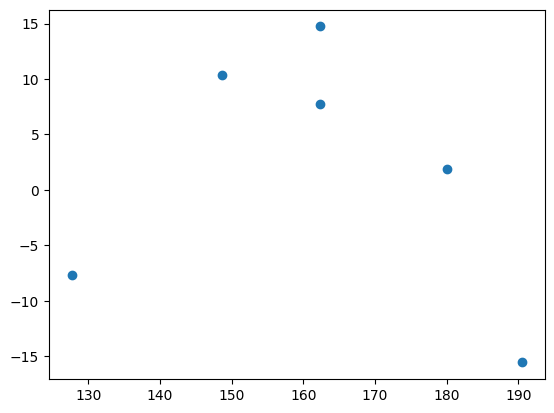

In [30]:
plt.scatter(y_pred, y_test-y_pred) ## this should be random 

In [ ]:
## to save model - we create a pickle file